In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('amazon_ecommerce_1M.csv')

In [5]:
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


In [6]:
print("--- Visão Geral dos Dados Financeiros e de Performance ---")
print(df[['price', 'discount', 'rating', 'review_count', 'shipping_time_days']].describe())

--- Visão Geral dos Dados Financeiros e de Performance ---
                price        discount          rating    review_count  \
count  1000000.000000  1000000.000000  1000000.000000  1000000.000000   
mean     13224.119093       28.996161        3.927226       32.626704   
std      18079.626921       14.681077        0.519443       43.382201   
min        200.030000        5.000000        1.500000        0.000000   
25%       2700.147500       16.910000        3.600000       10.000000   
50%       4971.830000       28.070000        3.900000       20.000000   
75%      14134.482500       39.240000        4.300000       39.000000   
max      79999.700000       70.000000        5.000000     3408.000000   

       shipping_time_days  
count      1000000.000000  
mean             3.166389  
std              1.674178  
min              1.000000  
25%              2.000000  
50%              3.000000  
75%              5.000000  
max              6.000000  


Tivemos alguns erros de 'NameError' durante a execução porque o ambiente do Colab reiniciou as variáveis constantemente, mas foi resolvido executando novamente a célula de importação dos dados.

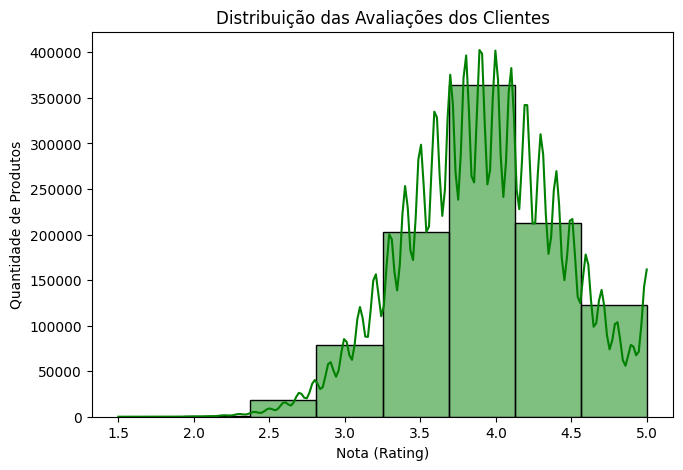

In [7]:
plt.figure(figsize=(7.5, 5))
sns.histplot(df['rating'], bins= 8, kde=True, color='green')
plt.title('Distribuição das Avaliações dos Clientes')
plt.xlabel('Nota (Rating)')
plt.ylabel('Quantidade de Produtos')
plt.show()

Gáfico acima, mostra a distribuição das notas dos compradores com base no produto que foi recebido.

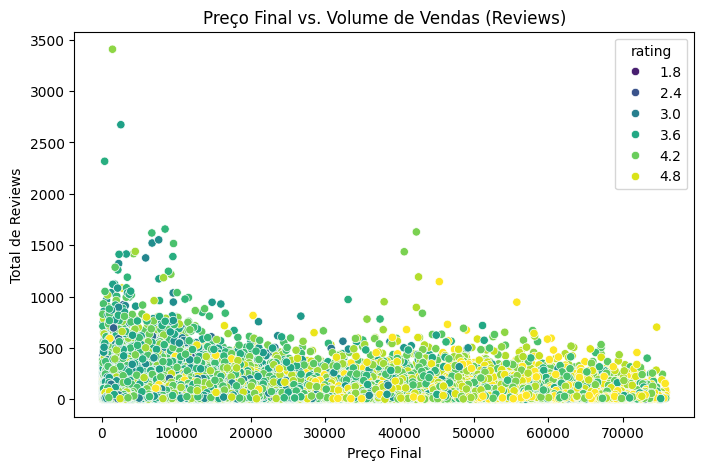

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='final_price', y='review_count', hue='rating', palette='viridis')
plt.title('Preço Final vs. Volume de Vendas (Reviews)')
plt.xlabel('Preço Final')
plt.ylabel('Total de Reviews')
plt.show()

Gráfico acima representa se os prdutos que obtém um preço mais alto tem uma taixa baixa de venda ou se o fornecimento do desconto ajuda o cliente a fechar a compra.

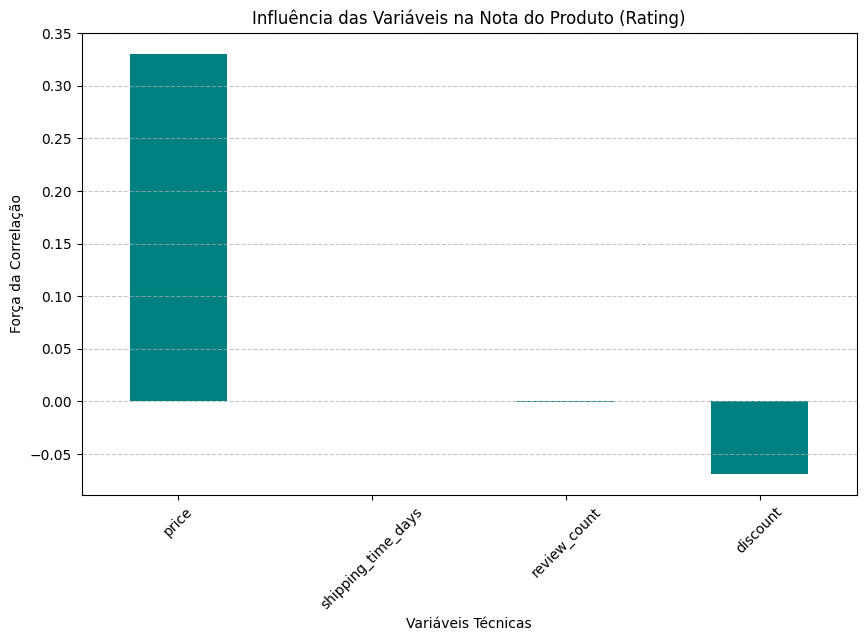

In [9]:
plt.figure(figsize=(10, 6))
correlation = df[['price', 'discount', 'rating', 'review_count', 'shipping_time_days']].corr()['rating'].sort_values(ascending=False)
correlation.drop('rating').plot(kind='bar', color='teal')

plt.title('Influência das Variáveis na Nota do Produto (Rating)')
plt.ylabel('Força da Correlação')
plt.xlabel('Variáveis Técnicas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Esse gráfico da base da Amazon foi criado no intuito de comparar as correlações focado no 'Rating', portanto mostra que o preço tem a **maior barra positiva** (**chegando a quase 0.35**), o que sugere que produtos com preço médio maior tendem a ter avaliações melhores nesta base (gerando uma melhor satisfação do cliente ao receber o produto); Já o desconto apareceu com uma ***leve correlação negativa***, indicando que baixar o preço sozinho não **garante uma nota maior** (há diversos fatores a se classificar um produto e não por ter a garantia do desconto sozinho).

In [10]:
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['review_count'] = df['review_count'].fillna(0)
df = df.dropna()

In [11]:
media_reviews = df['review_count'].mean()
media_envio = df['shipping_time_days'].mean()

df['target_escala'] = ((df['rating'] > 4.0) &
                       (df['review_count'] > media_reviews) &
                       (df['shipping_time_days'] <= media_envio)).astype(int)

print(f"Produtos em potencial escala identificados na base: {df['target_escala'].sum()}")

Produtos em potencial escala identificados na base: 71525


logo acima, **definição da target** - tendo destaque na concentração de dados referente a **preço**, **desconto** e **satisfação do cliente** na entrega e avaliação própria do produto.

In [12]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['mes_compra'] = df['purchase_date'].dt.month
df['dia_semana'] = df['purchase_date'].dt.dayofweek

transformando data em informações numéricas no qual o modelo conseguirá um melhor entedimento.

In [13]:
colunas_texto = ['category', 'subcategory', 'brand', 'location', 'device', 'payment_method', 'delivery_status']
df_final = pd.get_dummies(df, columns=colunas_texto, drop_first=True)

acima, obtemos variáveis categóricas convertidas por variáveis numéricas através do método One-Hot Encoding.

In [14]:
scaler = StandardScaler()

cols_num = ['price', 'discount', 'final_price', 'review_count', 'stock', 'seller_rating', 'shipping_time_days', 'mes_compra', 'dia_semana']
df_final[cols_num] = scaler.fit_transform(df_final[cols_num])

Obtém uma garantia do equilibrio entre variáveis com valores muito altos não tendo uma diferença de peso para variáveis baixas na hora de realizar o cálculo do modelo.

In [15]:
print("Pipeline de Pré-processamento finalizado!")
print("O DataFrame 'df_final' está pronto para realização da etapa modelagem")

Pipeline de Pré-processamento finalizado!
O DataFrame 'df_final' está pronto para realização da etapa modelagem


In [16]:
from sklearn.model_selection import train_test_split

IMPORTANDO MODELO DE TREINO E TESTE

In [17]:
colunas_excluir = [c for c in ['target_escala', 'purchase_date',
                                'user_id', 'product_id', 'seller_id']
                   if c in df_final.columns]


DEFININDO COLUNAS QUE NAO SAO FEATURES UTILIZAVEIS

In [18]:
X = df_final.drop(columns=colunas_excluir)
y = df_final['target_escala']

EXCLUINDO AS COLUNAS

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print(f"Formato do conjunto de TREINO: X={X_train.shape}, y={y_train.shape}")
print(f"Formato do conjunto de TESTE:  X={X_test.shape},  y={y_test.shape}")
print(f"\nDistribuição da target no TREINO:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nDistribuição da target no TESTE:\n{y_test.value_counts(normalize=True).round(4)}")

Formato do conjunto de TREINO: X=(700000, 53), y=(700000,)
Formato do conjunto de TESTE:  X=(300000, 53),  y=(300000,)

Distribuição da target no TREINO:
target_escala
0    0.9285
1    0.0715
Name: proportion, dtype: float64

Distribuição da target no TESTE:
target_escala
0    0.9285
1    0.0715
Name: proportion, dtype: float64


DEFININDO TREINO 70% TESTE 30%

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

IMPORTANDO OS 3 CLASSIFICADORES

In [21]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

100 ARVORES NA FLORESTA E USA TODOSM OS NUCLEOS DO PROCESSADOR(N_JOBS=-1)

In [22]:
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

CONSIDERA OS 5 VIZINHOS MAIS PROXIMOS

In [23]:
modelo_svc = LinearSVC(
    random_state=42,
    max_iter=2000,
    dual='auto'
)
print("3 classificadores instanciados: RandomForest, KNN, LinearSVC")

3 classificadores instanciados: RandomForest, KNN, LinearSVC


DEFINE LIMITE DE 2000 ITERAÇÕES DEVIDO AO TAMANHO DA DB

In [24]:
from sklearn.ensemble import VotingClassifier
comite = VotingClassifier(
    estimators=[
        ('rf',  modelo_rf),
        ('knn', modelo_knn),
        ('svc', modelo_svc),
    ],
    voting='hard'
)
print("Comitê de Classificadores criado (VotingClassifier, votação hard)")

Comitê de Classificadores criado (VotingClassifier, votação hard)


DEFINE QUE CADA MODELO VOTARÁ EM 1 OU 0. A CLASSE COM MAIS VOTOS VENCE

In [25]:
import time
inicio = time.time()
print("Treinando o Comitê de Classificadores... Aguarde.")
comite.fit(X_train, y_train)
fim = time.time()
print(f"Treinamento concluído em {fim - inicio:.1f} segundos.")

Treinando o Comitê de Classificadores... Aguarde.
Treinamento concluído em 25.9 segundos.


REALIZA O TREINO X,Y DO MODELO E EXIBE O TEMPO DE EXECUÇÃO (16GB DE RAM CONSUMIDA, CUIDADO AO RODAR)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = comite.predict(X_test)
print("RESULTADOS DO COMITÊ DE CLASSIFICADORES")
print(f"\nAcurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nRelatório de Classificação:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Sem Potencial (0)', 'Com Potencial (1)']
))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

RESULTADOS DO COMITÊ DE CLASSIFICADORES

Acurácia: 0.9493

Relatório de Classificação:

                   precision    recall  f1-score   support

Sem Potencial (0)       0.95      1.00      0.97    278543
Com Potencial (1)       0.98      0.30      0.46     21457

         accuracy                           0.95    300000
        macro avg       0.96      0.65      0.72    300000
     weighted avg       0.95      0.95      0.94    300000

Matriz de Confusão:
[[278410    133]
 [ 15065   6392]]


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

resultados = []

metodo_media = 'weighted'


Treinando cada um dos classificadores e registra


In [28]:
for nome, modelo_treinado in comite.named_estimators_.items():

    y_pred_ind = modelo_treinado.predict(X_test)

    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred_ind),
        'Precisão': precision_score(y_test, y_pred_ind, average=metodo_media),
        'Recall': recall_score(y_test, y_pred_ind, average=metodo_media),
        'F1-Score': f1_score(y_test, y_pred_ind, average=metodo_media),
        'Matriz de Confusão': str(confusion_matrix(y_test, y_pred_ind).tolist())
    })


Avaliando o comitê

In [29]:
y_pred_comite = comite.predict(X_test) # <-- Gerando a predição real do comitê

resultados.append({
    'Modelo': 'Comitê (Voting - Hard)',
    'Acurácia': accuracy_score(y_test, y_pred_comite),
    'Precisão': precision_score(y_test, y_pred_comite, average=metodo_media),
    'Recall': recall_score(y_test, y_pred_comite, average=metodo_media), # <-- Adicionado o Recall
    'F1-Score': f1_score(y_test, y_pred_comite, average=metodo_media),
    'Matriz de Confusão': str(confusion_matrix(y_test, y_pred_comite).tolist())
})

Foi observado vazamento de dados/overtifitng no random forest em decorrencia de se tratar de um ML de regressão linear que enxergou nossa lógica de definição de target e "trapaceou". 

In [30]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.round(4)
display(df_resultados)

,Modelo,Acurácia,Precisão,Recall,F1-Score,Matriz de Confusão
0,rf,1.0000,1.0000,1.0000,1.0000,"[[278543, 0], [0, 21457]]"
1,knn,0.9397,0.9300,0.9397,0.9251,"[[276764, 1779], [16299, 5158]]"
2,svc,0.9343,0.9211,0.9343,0.9132,"[[277323, 1220], [18492, 2965]]"
3,Comitê (Voting - Hard),0.9493,0.9509,0.9493,0.9365,"[[278410, 133], [15065, 6392]]"
